<a href="https://colab.research.google.com/github/Walnut235/olist-probabilistic-analysis/blob/main/notebooks/01_analisis_olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Probabilístico del E-Commerce Brasileño — Olist

## Machine Learning Probabilístico

**Dataset:** Brazilian E-Commerce Public Dataset by Olist

### Objetivo

Analizar el comportamiento del comercio electrónico de Olist mediante conceptos de probabilidad, estadística e información, con el fin de identificar patrones relevantes para la toma de decisiones.

### Conceptos a estudiar

1. Probabilidad condicional
2. Teorema de Bayes
3. Verosimilitud
4. Máxima verosimilitud (MLE)
5. Distribuciones paramétricas
6. Esperanza y varianza
7. Independencia y correlación
8. Prior y posterior
9. Entropía
10. Entropía cruzada
11. Divergencia KL

# Cargar datos

**Importar librerias**

In [125]:
!pip install -q kagglehub #descargar conexión con kaggle

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub
import os
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import entropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

**Descarga del dataset de Olist**

In [127]:

# Descargar el dataset de Olist
dataset_path = kagglehub.dataset_download(
    "olistbr/brazilian-ecommerce"
)

print("Dataset descargado en:")
print(dataset_path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset descargado en:
/kaggle/input/brazilian-ecommerce


**Carga de las tablas**

In [128]:
dataset_path = "/kaggle/input/brazilian-ecommerce"

# Obtener únicamente los archivos CSV
files = [
    file for file in os.listdir(dataset_path)
    if file.endswith(".csv")
]
# Diccionario para almacenar las tablas
data = {}

for file in files:
    file_path = os.path.join(dataset_path, file)

    # Nombre de la tabla sin .csv
    table_name = file.replace(".csv", "")

    # Cargar tabla
    data[table_name] = pd.read_csv(file_path)

print("\nTablas cargadas correctamente:")

for name, df in data.items():
    print(f"{name}: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Tablas cargadas correctamente:
olist_customers_dataset: 99,441 filas × 5 columnas
olist_sellers_dataset: 3,095 filas × 4 columnas
olist_order_reviews_dataset: 99,224 filas × 7 columnas
olist_order_items_dataset: 112,650 filas × 7 columnas
olist_products_dataset: 32,951 filas × 9 columnas
olist_geolocation_dataset: 1,000,163 filas × 5 columnas
product_category_name_translation: 71 filas × 2 columnas
olist_orders_dataset: 99,441 filas × 8 columnas
olist_order_payments_dataset: 103,886 filas × 5 columnas


**Conocer las tablas**

In [129]:
for name, df in data.items(): # recorrer el diccionario
    print(f"\n{'=' * 60}")
    print(name) # nombre de la tabla
    print(f"{'=' * 60}")
    print("Columnas:")

    for column in df.columns: # mostrar las columnas del df
        print(f"  - {column}")



olist_customers_dataset
Columnas:
  - customer_id
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state

olist_sellers_dataset
Columnas:
  - seller_id
  - seller_zip_code_prefix
  - seller_city
  - seller_state

olist_order_reviews_dataset
Columnas:
  - review_id
  - order_id
  - review_score
  - review_comment_title
  - review_comment_message
  - review_creation_date
  - review_answer_timestamp

olist_order_items_dataset
Columnas:
  - order_id
  - order_item_id
  - product_id
  - seller_id
  - shipping_limit_date
  - price
  - freight_value

olist_products_dataset
Columnas:
  - product_id
  - product_category_name
  - product_name_lenght
  - product_description_lenght
  - product_photos_qty
  - product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm

olist_geolocation_dataset
Columnas:
  - geolocation_zip_code_prefix
  - geolocation_lat
  - geolocation_lng
  - geolocation_city
  - geolocation_state

product_category_name_tr

**Verificar relaciones (1:N, 1:1, M:N)**

In [130]:
# ¿Cada customer_id aparece una sola vez?
print("CUSTOMERS")
print("customer_id únicos:", data["olist_customers_dataset"]["customer_id"].nunique())
print("filas:", len(data["olist_customers_dataset"]))

print("\nORDERS")
print("order_id únicos:", data["olist_orders_dataset"]["order_id"].nunique())
print("filas:", len(data["olist_orders_dataset"]))

print("\nPRODUCTS")
print("product_id únicos:", data["olist_products_dataset"]["product_id"].nunique())
print("filas:", len(data["olist_products_dataset"]))

print("\nSELLERS")
print("seller_id únicos:", data["olist_sellers_dataset"]["seller_id"].nunique())
print("filas:", len(data["olist_sellers_dataset"]))

print("\nREVIEWS")
print("order_id únicos:", data["olist_order_reviews_dataset"]["order_id"].nunique())
print("filas:", len(data["olist_order_reviews_dataset"]))

print("\nORDER ITEMS")
print("order_id únicos:", data["olist_order_items_dataset"]["order_id"].nunique())
print("filas:", len(data["olist_order_items_dataset"]))

CUSTOMERS
customer_id únicos: 99441
filas: 99441

ORDERS
order_id únicos: 99441
filas: 99441

PRODUCTS
product_id únicos: 32951
filas: 32951

SELLERS
seller_id únicos: 3095
filas: 3095

REVIEWS
order_id únicos: 98673
filas: 99224

ORDER ITEMS
order_id únicos: 98666
filas: 112650


**Union de las tablas**

In [131]:
# Guardar cada tabla en un df individual
orders = data["olist_orders_dataset"].copy()
customers = data["olist_customers_dataset"].copy()
items = data["olist_order_items_dataset"].copy()
products = data["olist_products_dataset"].copy()
sellers = data["olist_sellers_dataset"].copy()
reviews = data["olist_order_reviews_dataset"].copy()
payments = data["olist_order_payments_dataset"].copy()
geolocation = data["olist_geolocation_dataset"].copy()
category_translation = data["product_category_name_translation"].copy()

In [132]:
df_master = orders.copy()

print("INICIAL")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

INICIAL
Filas: 99441
Pedidos únicos: 99441


In [133]:
df_master = df_master.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one" #Relación 1:1
)

print("DESPUÉS DE CUSTOMERS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE CUSTOMERS
Filas: 99441
Pedidos únicos: 99441


In [134]:
df_master = df_master.merge(
    items,
    on="order_id",
    how="left",
    validate="one_to_many"
)

print("DESPUÉS DE ORDER_ITEMS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE ORDER_ITEMS
Filas: 113425
Pedidos únicos: 99441


In [135]:
df_master = df_master.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("DESPUÉS DE PRODUCTS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE PRODUCTS
Filas: 113425
Pedidos únicos: 99441


In [136]:
df_master = df_master.merge(
    sellers,
    on="seller_id",
    how="left",
    validate="many_to_one"
)

print("DESPUÉS DE SELLERS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE SELLERS
Filas: 113425
Pedidos únicos: 99441


In [137]:
df_master = df_master.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

print("DESPUÉS DE CATEGORY TRANSLATION")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE CATEGORY TRANSLATION
Filas: 113425
Pedidos únicos: 99441


### Construcción y alcance del DataFrame maestro

Para la construcción del DataFrame maestro se realizaron uniones (`merge`) progresivas tomando como base la tabla `olist_orders_dataset`, donde cada registro representa un pedido. Primero se incorporó la información de los clientes mediante `customer_id` y posteriormente la información de los productos y vendedores a través de `order_items`, utilizando `product_id` y `seller_id`, respectivamente. Finalmente, se incorporó la traducción de las categorías mediante `product_category_name`. Se utilizaron uniones de tipo `left` para conservar los 99.441 pedidos originales, incluso cuando estos no contaban con información asociada en alguna de las tablas. Como resultado, el DataFrame pasó de 99.441 filas a 113.425 debido a que un mismo pedido puede contener varios productos. Las tablas de reseñas (`reviews`) y pagos (`payments`) no se incorporaron directamente al DataFrame maestro, ya que pueden contener múltiples registros asociados a un mismo pedido y podrían alterar su granularidad; estas serán agregadas posteriormente a nivel de `order_id` según las necesidades de cada análisis. La tabla de geolocalización tampoco se incorporó al DataFrame maestro debido a su gran cantidad de registros y a que un mismo código postal puede aparecer múltiples veces. Durante el proyecto, este DataFrame se utilizará como base para los análisis relacionados con pedidos, productos, categorías y vendedores, teniendo siempre en cuenta su granularidad de pedido-producto. Cuando un análisis requiera contar pedidos, clientes u otras entidades, se utilizarán identificadores únicos mediante `nunique()`, y cuando sea necesario obtener variables a nivel de pedido se realizarán las agregaciones correspondientes antes del análisis.

# limpieza de los datos

In [138]:
df_master.head() #Visulizar las 5 primeras filas

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery


**Dejar solo las variables relevantes para el análisis**

In [139]:
variables_master = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_state",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "price",
    "freight_value",
    "seller_id",
    "seller_state",
    "product_category_name",
    "product_weight_g"
]

df_master = df_master[variables_master].copy()

print("Variables seleccionadas:")
print(df_master.columns.tolist())

print("\nDimensiones:")
print(df_master.shape)

Variables seleccionadas:
['order_id', 'customer_id', 'customer_unique_id', 'customer_state', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'price', 'freight_value', 'seller_id', 'seller_state', 'product_category_name', 'product_weight_g']

Dimensiones:
(113425, 14)


In [140]:
print("Columnas con valores faltantes:")
df_master.isna().sum() # Mirar que columnas tienen valores faltantes

Columnas con valores faltantes:


,0
order_id,0
customer_id,0
customer_unique_id,0
customer_state,0
order_status,0
order_purchase_timestamp,0
order_delivered_customer_date,3229
order_estimated_delivery_date,0
price,775
freight_value,775


In [141]:
df_master.dtypes #Mirar tipo de dato por columna

,0
order_id,object
customer_id,object
customer_unique_id,object
customer_state,object
order_status,object
order_purchase_timestamp,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
price,float64
freight_value,float64


**Conversión de tipos de datos (fechas)**

In [142]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_master[col] = pd.to_datetime(df_master[col], errors="coerce") #Convertir columnas de fechas a tipo datetime

print("Tipos de datos después de la conversión:")
print(df_master[date_cols].dtypes)


Tipos de datos después de la conversión:
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Diagnóstico de valores faltantes por `order_status`**

Antes de decidir qué hacer con cada columna con NaN, revisamos si los faltantes están relacionados con el estado del pedido (`order_status`). Esto nos permite distinguir entre un dato *realmente perdido* y un dato que *no existe porque el pedido nunca llegó a esa etapa* (por ejemplo, un pedido cancelado nunca tendrá fecha de entrega).

In [143]:
missing_delivery_orders = (
    df_master[df_master["order_delivered_customer_date"].isna()] # Filtrar los que no tienen fecha de entrega
    .drop_duplicates("order_id") #Trabajar a nivel de cada orden y no de item
)

print("Pedidos únicos sin fecha de entrega:", len(missing_delivery_orders))
print("\nDistribución de order_status:")
print(missing_delivery_orders["order_status"].value_counts())

Pedidos únicos sin fecha de entrega: 2965

Distribución de order_status:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


 El pedido nunca fue entregado (shipped, canceled, unavailable, invoiced, processing) o, en 8 casos, quedó marcado `delivered` sin fecha registrada (inconsistencia del dato original)

In [144]:
missing_items_orders = (
    df_master[df_master["price"].isna()]
    .drop_duplicates("order_id")
)

print("Pedidos únicos sin ítem asociado:", len(missing_items_orders))
print("\nDistribución de order_status:")
print(missing_items_orders["order_status"].value_counts())

Pedidos únicos sin ítem asociado: 775

Distribución de order_status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


 El pedido no tiene ningún ítem asociado en `olist_order_items_dataset`

In [145]:
missing_category = df_master[df_master["product_category_name"].isna()]# analisis de items, filtrar aquellos sin categoria
missing_weight = df_master[df_master["product_weight_g"].isna()]# analisis de items, filtrar aquellos sin peso

print("Filas sin categoría de producto:", len(missing_category))
print("Pedidos únicos afectados por falta de categoria:", missing_category["order_id"].nunique())# número de pedidos con algun item sin categoria
print("\nDistribución de order_status (categoría faltante):")
print(missing_category["order_status"].value_counts())

print("\nFilas sin peso de producto:", len(missing_weight))
print("Pedidos únicos afectados:", missing_weight["order_id"].nunique())# número de pedidos con algun item sin peso

Filas sin categoría de producto: 2378
Pedidos únicos afectados por falta de categoria: 2226

Distribución de order_status (categoría faltante):
order_status
delivered      1537
unavailable     603
canceled        178
shipped          28
invoiced         14
processing       13
created           5
Name: count, dtype: int64

Filas sin peso de producto: 793
Pedidos únicos afectados: 791


Inconsistencia conocida del dataset original de Olist, hay productos (`product_id`) sin categoría registrada en `olist_products_dataset`.Lo mismo pasa en el caso de los pesos de los productos.

**Tratamiento de valores faltantes**

No aplicamos `dropna()` global. Cada columna con NaN se trata según **por qué** falta el dato:

| Columna | NaN | Tratamiento |
|---|---|---|
| `order_delivered_customer_date` | 3.229 filas / 2.965 pedidos |  **Se conserva como NaN.** No se imputa una fecha inventada. Se usa para construir la variable derivada `retrasado`, que quedará en `NaN` quan no se pueda determinar. |
| `price`, `freight_value`, `seller_id`, `seller_state` | 775 filas | **Se conservan como NaN.** Estas filas se excluyen puntualmente solo en los análisis que dependen de precio/flete/vendedor (ej. esperanza y varianza del ticket, independencia pago–categoría), no se eliminan del DataFrame completo. |
| `product_category_name` | 2.378 filas | **Se imputa con la etiqueta `"sin_categoria"`** en lugar de NaN, para que estos productos sí cuenten como una categoría propia en los análisis de entropía e independencia (ignorarlos silenciosamente subestimaría la diversidad real del catálogo). |
| `product_weight_g` | 793 filas |  **Se conserva como NaN** y se excluye únicamente del análisis de distribución paramétrica del peso (no se imputa un peso, porque inventar un valor numérico sí distorsionaría el ajuste de la distribución). |

Ningún pedido se elimina del DataFrame por tener NaN en estas columnas — solo se excluye puntualmente de los análisis específicos que requieren esa variable.

In [146]:
df_clean = df_master.copy()

# Imputación puntual de product_category_name
df_clean["product_category_name"] = df_clean["product_category_name"].fillna("sin_categoria")#imputar "Sin categoria" cuando esta haga falta, a nivel de item

print("df_clean creado.")
print("Filas:", len(df_clean))
print("Columnas:", len(df_clean.columns))
print("\nValores faltantes restantes:")
print(df_clean.isna().sum())

df_clean creado.
Filas: 113425
Columnas: 14

Valores faltantes restantes:
order_id                            0
customer_id                         0
customer_unique_id                  0
customer_state                      0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    3229
order_estimated_delivery_date       0
price                             775
freight_value                     775
seller_id                         775
seller_state                      775
product_category_name               0
product_weight_g                  793
dtype: int64


**Variable derivada: `retrasado`**

Regla (ya definida): solo se clasifica un pedido como retrasado / no retrasado si fue efectivamente **entregado** y tiene fecha real de entrega. En cualquier otro caso, `retrasado = NaN` (no sabemos, no inventamos).

In [147]:
# Filas que tienen fecha de entrega pero NO están en estado delivered
inconsistencias = df_clean[
    df_clean["order_delivered_customer_date"].notna() &
    (df_clean["order_status"] != "delivered")
]

print("Filas con fecha de entrega pero estado diferente de 'delivered':", len(inconsistencias))

if len(inconsistencias) == 0:
    print("✓ Todos los registros con fecha de entrega pertenecen a pedidos 'delivered'.")
else:
    print("\nEstados encontrados:")
    print(inconsistencias["order_status"].value_counts())

Filas con fecha de entrega pero estado diferente de 'delivered': 7

Estados encontrados:
order_status
canceled    7
Name: count, dtype: int64


Estos registros fueron cancelados, pero aun así tienen una fecha de entrega registrada, lo cual representa una inconsistencia. A falta de información sobre su causa exacta, existen dos explicaciones plausibles: (1) un error de registro en la fecha, o (2) un fenómeno real, en el que el pedido llegó a entregarse (o inició su proceso logístico) y solo después fue cancelado en el sistema.

Como no es posible distinguir entre ambos escenarios con la información disponible, no se sobrescribe order_status ni se asume que la fecha implica una entrega real. Estos pedidos se conservan tal como están y, en consecuencia, quedan fuera de la clasificación de retrasado (NaN), igual que el resto de pedidos no entregados. Esta inconsistencia se documenta como limitación conocida del dataset, junto con los 8 casos delivered sin fecha.

In [148]:
fue_entregado = (
    (df_clean["order_status"] == "delivered") &
    (df_clean["order_delivered_customer_date"].notna())#asi se excluyen los registros que fueron entregados pero no tienen fecha de entrega registrada
)

df_clean["retrasado"] = np.where(
    fue_entregado, #¿pertenece a fue entregado?
    (df_clean["order_delivered_customer_date"] > df_clean["order_estimated_delivery_date"]).astype(int),
    np.nan #de lo contrario NaN
)

print("Distribución de 'retrasado' (incluye NaN = no clasificable):")
print(df_clean["retrasado"].value_counts(dropna=False))

print("\nPedidos únicos clasificables:", df_clean.loc[df_clean["retrasado"].notna(), "order_id"].nunique())

Distribución de 'retrasado' (incluye NaN = no clasificable):
retrasado
0.0    101475
1.0      8714
NaN      3236
Name: count, dtype: int64

Pedidos únicos clasificables: 96470


**Validaciones de consistencia**

In [149]:
print("1) Precios y fletes negativos:")
print("   price < 0:", (df_clean["price"] < 0).sum())
print("   freight_value < 0:", (df_clean["freight_value"] < 0).sum())

print("\n2) Consistencia cronológica (compra <= entrega, cuando hay fecha real):")
inconsistentes = df_clean[
    df_clean["order_delivered_customer_date"].notna() &
    (df_clean["order_delivered_customer_date"] < df_clean["order_purchase_timestamp"])
]
print("   Pedidos con fecha de entrega ANTES de la compra:", inconsistentes["order_id"].nunique())

print("\n3) Rango de fechas del dataset:")
print("   Compra: ", df_clean["order_purchase_timestamp"].min(), "→", df_clean["order_purchase_timestamp"].max())

1) Precios y fletes negativos:
   price < 0: 0
   freight_value < 0: 0

2) Consistencia cronológica (compra <= entrega, cuando hay fecha real):
   Pedidos con fecha de entrega ANTES de la compra: 0

3) Rango de fechas del dataset:
   Compra:  2016-09-04 21:15:19 → 2018-10-17 17:30:18


# Concepto 1 — Probabilidad condicional

**Pregunta de negocio:** ¿La demora en la entrega se asocia con reseñas negativas?

In [150]:
reviews = data["olist_order_reviews_dataset"]

# Número de reseñas y puntuaciones diferentes por pedido
reviews_por_pedido = (
    reviews
    .groupby("order_id")
    .agg(
        num_reseñas=("review_id", "count"),
        num_puntuaciones=("review_score", "nunique")
    )
)

# Pedidos con más de una reseña
multiples_reseñas = reviews_por_pedido[
    reviews_por_pedido["num_reseñas"] > 1
]

print("Pedidos con múltiples reseñas:", len(multiples_reseñas))

print(
    "Pedidos con múltiples reseñas y puntuaciones diferentes:",
    (multiples_reseñas["num_puntuaciones"] > 1).sum()
)

print("\nDistribución del número de reseñas por pedido:")
print(multiples_reseñas["num_reseñas"].value_counts().sort_index())

print("\nPedidos con puntuaciones diferentes:")
print(
    multiples_reseñas[
        multiples_reseñas["num_puntuaciones"] > 1
    ]
)

Pedidos con múltiples reseñas: 547
Pedidos con múltiples reseñas y puntuaciones diferentes: 202

Distribución del número de reseñas por pedido:
num_reseñas
2    543
3      4
Name: count, dtype: int64

Pedidos con puntuaciones diferentes:
                                  num_reseñas  num_puntuaciones
order_id                                                       
013056cfe49763c6f66bda03396c5ee3            2                 2
02355020fd0a40a0d56df9f6ff060413            2                 2
029863af4b968de1e5d6a82782e662f5            2                 2
03c939fd7fd3b38f8485a0f95798f1f6            3                 2
03eba6d9fef8f5b3e811d4b5a7cca9cd            2                 2
...                                       ...               ...
fa350da9efbba83c2957b629bf6c2c7c            2                 2
fc3d87913825143fa41c48e40267c47a            2                 2
fcde2f7449493b4f207a23fae117b0fb            2                 2
fd61441ba2a7b57e6342862e779b10b0            2             

**Tratamiento de múltiples reseñas**: Se identificaron 547 pedidos con más de una reseña, de los cuales 202 presentan puntuaciones diferentes entre sus reseñas. Debido a que estos casos representan una proporción muy pequeña del conjunto de pedidos, se conservaron todas las reseñas disponibles para el análisis probabilístico. Por tanto, la unidad de análisis para la probabilidad condicional será la reseña, asociando a cada una las características del pedido correspondiente. Esta decisión permite conservar la información disponible sin seleccionar arbitrariamente una única reseña por pedido. Los resultados se interpretarán como probabilidades asociadas a reseñas y no directamente como probabilidades asociadas a pedidos.

**Crear un dataset que incluya las reseñas**

In [151]:
orders_analysis = (
    df_clean[
        [
            "order_id",
            "order_delivered_customer_date",  #incluir las caracteristicas necesarias para el analisis
            "order_estimated_delivery_date"
        ]
    ]
    .drop_duplicates("order_id") #Dejar solo un order_id para evitar duplicar reseñas al hacer el merge
)

orders_analysis["tardio"] = (
    orders_analysis["order_delivered_customer_date"]  #calcular si una orden llego tarde comparando la fecha de entrega con la fecha estimada de entrega
    > orders_analysis["order_estimated_delivery_date"]
)

reviews_analysis = (
    data["olist_order_reviews_dataset"][
        ["review_id", "order_id", "review_score"] #Unir los datasets para obtener uno que incluya las reseñas
    ]
    .merge(
        orders_analysis,
        on="order_id",
        how="inner"
    )
)

reviews_analysis["reseña_negativa"] = (
    reviews_analysis["review_score"] <= 2  #Identificar las reseñas negativas en una columna boleana
)

grupo_tardio = reviews_analysis[
    reviews_analysis["tardio"]
]

p_tardio_y_negativa =  (
    reviews_analysis["tardio"] &
    reviews_analysis["reseña_negativa"]
).mean()

p_tardio = reviews_analysis["tardio"].mean() # número de

p_negativa_dado_tardio = p_tardio_y_negativa / p_tardio

print("Numerador:", p_tardio_y_negativa)
print("Denominador:", p_tardio)

print(
    f"P(reseña < 2 | pedido tardío) = {p_negativa_dado_tardio:.4f}"
)

print(
    f"Porcentaje = {p_negativa_dado_tardio * 100:.2f}%"
)
print("Reseñas asociadas a pedidos tardíos:", len(grupo_tardio))

print(
    "Reseñas menores a 2 estrellas:",
    grupo_tardio["reseña_negativa"].sum()
)

print(
    "Pedidos únicos representados:",
    reviews_analysis["order_id"].nunique()
)

Numerador: 0.041925340643392726
Denominador: 0.0776122712247037
P(reseña < 2 | pedido tardío) = 0.5402
Porcentaje = 54.02%
Reseñas asociadas a pedidos tardíos: 7701
Reseñas menores a 2 estrellas: 4160
Pedidos únicos representados: 98673


La probabilidad de que una reseña tenga una puntuación menor o igual a 2 sabiendo que la orden a la que esta asociada llego con tardanza es de 0.5402.

Esto significa que aproximadamente el 54% de las reseñas asociadas a pedidos que llegaron tarde presentan una puntuación de 2 estrellas o menos.

# Concepto 2 — Teorema de Bayes

**Pregunta de negocio:** Si un pedido recibió una reseña negativa, ¿qué tan probable es que haya llegado tarde?

Ya calculamos en el punto anterior: $$P(reseña negativa∣pedido tardío)=0.5402$$
Ahora usando bayes podemos obtener $$P(pedido tardío∣reseña negativa)$$
Usando la fórmula: $$P(tardío|negativa) = \frac{P(negativa|tardío)P(tardío)}{P(negativa)}$$

In [152]:
p_negativa = reviews_analysis["reseña_negativa"].mean()
p_tardio_dado_negativa = (
    p_negativa_dado_tardio * p_tardio
) / p_negativa

print(f"P(negativa | tardío): {p_negativa_dado_tardio:.4f}")
print(f"P(tardío): {p_tardio:.4f}")
print(f"P(negativa): {p_negativa:.4f}")
print(f"P(tardío ∩ negativa): {p_tardio_y_negativa:.4f}")
print(f"P(tardío | negativa): {p_tardio_dado_negativa:.4f}")

P(negativa | tardío): 0.5402
P(tardío): 0.0776
P(negativa): 0.1469
P(tardío ∩ negativa): 0.0419
P(tardío | negativa): 0.2854


Utilizando el teorema de bayes se llego a que la probabilidad de que un pedido sea tardio dado que tuvo un puntaje en la reseña menor o igual a 2 es de 0.2854

# Concepto 3 — Verosimilitud / MLE

**Pregunta de negocio:** ¿Qué distribución de probabilidad describe mejor el tiempo de entrega, y qué tan bien se ajusta frente a una alternativa?

In [153]:
df_clean["tiempo_entrega_dias"] = (     #calcular el tiempo de entrega
    df_clean["order_delivered_customer_date"] -
    df_clean["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)



**Ajustar las distribuciones propuestas**

In [154]:
x = df_clean["tiempo_entrega_dias"].values

x_clean = x[np.isfinite(x)]# Filtrar solo los valores finitos (elimina NaN e inf)

lognorm_params = stats.lognorm.fit(x_clean, floc=0)# Ajustar los parámetros de la distribución
print("Parámetros Log-Normal:")
print("sigma =", lognorm_params[0])
print("loc   =", lognorm_params[1])
print("scale =", lognorm_params[2])

Parámetros Log-Normal:
sigma = 0.6792084028065883
loc   = 0
scale = 9.978475467921022


In [155]:
gamma_params = stats.gamma.fit(x_clean, floc=0)

print("Parámetros Gamma:")
print("shape =", gamma_params[0])
print("loc   =", gamma_params[1])
print("scale =", gamma_params[2])

Parámetros Gamma:
shape = 2.3945423095861877
loc   = 0
scale = 5.208774338385863


**Evaluar los dos ajustes**

In [156]:
loglik_lognorm = np.sum(
    stats.lognorm.logpdf(x_clean, *lognorm_params)
)

loglik_gamma = np.sum(
    stats.gamma.logpdf(x_clean, *gamma_params)
)

n = len(x_clean)

k_lognorm = len(lognorm_params)
k_gamma = len(gamma_params)

aic_lognorm = 2*k_lognorm - 2*loglik_lognorm
aic_gamma = 2*k_gamma - 2*loglik_gamma

bic_lognorm = k_lognorm*np.log(n) - 2*loglik_lognorm
bic_gamma = k_gamma*np.log(n) - 2*loglik_gamma

print("Log-Normal")
print("Log-Likelihood:", loglik_lognorm)
print("AIC:", aic_lognorm)
print("BIC:", bic_lognorm)

print("\nGamma")
print("Log-Likelihood:", loglik_gamma)
print("AIC:", aic_gamma)
print("BIC:", bic_gamma)

Log-Normal
Log-Likelihood: -367232.7520263466
AIC: 734471.5040526933
BIC: 734500.3341003255

Gamma
Log-Likelihood: -369334.95012702927
AIC: 738675.9002540585
BIC: 738704.7303016908


**Visualizar las distribuciones propuestas frente a los datos**

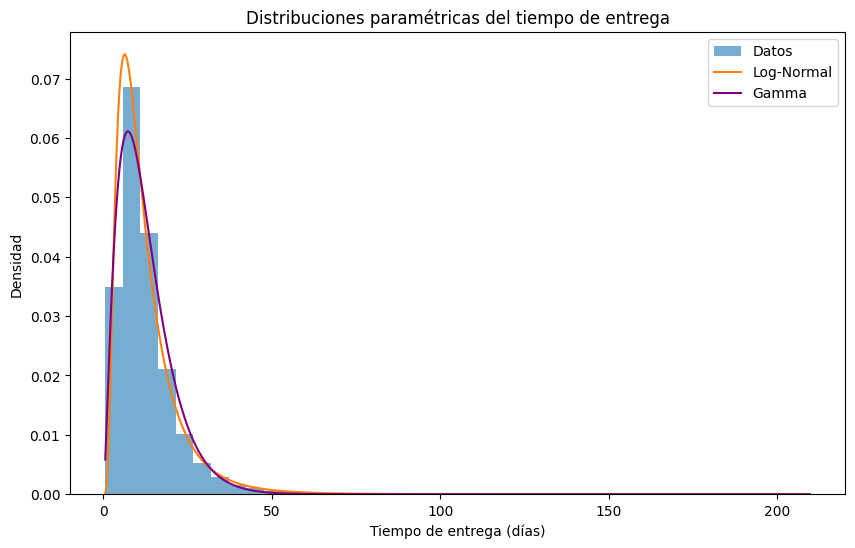

In [157]:
plt.figure(figsize=(10,6))

plt.hist(
    x_clean,
    bins=40,
    density=True,
    alpha=0.6,
    label="Datos"
)

x_grid = np.linspace(x_clean.min(), x_clean.max(), 500)

plt.plot(
    x_grid,
    stats.lognorm.pdf(x_grid, *lognorm_params),
    label="Log-Normal"
)

plt.plot(
    x_grid,
    stats.gamma.pdf(x_grid, *gamma_params),
    label="Gamma",
    color="purple"
)

plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Densidad")
plt.title("Distribuciones paramétricas del tiempo de entrega")
plt.legend()
plt.show()

### Selección del modelo: Log-Normal

Se ajustaron por Máxima Verosimilitud (MLE) dos distribuciones candidatas al tiempo de entrega (en días): Log-Normal y Gamma. Los resultados fueron:

| Distribución | Log-verosimilitud | AIC | BIC |
|---|---|---|---|
| **Log-Normal** | **−367.232,75** | **734.471,50** | **734.500,33** |
| Gamma | −369.334,95 | 738.675,90 | 738.704,73 |

La Log-Normal presenta mayor log-verosimilitud y menores AIC/BIC que la Gamma, con una diferencia de 4.204,4 en ambos criterios de información. Dado que ambas distribuciones tienen el mismo número de parámetros ($k=2$: forma y escala, con $loc=0$ fijo), la penalización por complejidad de AIC y BIC es idéntica para las dos — la diferencia observada refleja exclusivamente una mejor capacidad de ajuste de la Log-Normal a los datos, y no un efecto de parsimonia.

**Se selecciona la distribución Log-Normal** como el modelo paramétrico del tiempo de entrega. Esta elección es además coherente con la interpretación física del proceso: el tiempo total de entrega resulta de la combinación de múltiples etapas logísticas en cadena (procesamiento del pedido, tránsito, última milla), un mecanismo generador de tipo multiplicativo, que es precisamente el que da origen teórico a una distribución Log-Normal.

# Concepto 4 — Distribuciones paramétricas

**Pregunta de negocio:** ¿Qué distribución paramétrica describe mejor el peso de los paquetes o el valor de los pedidos, y qué evidencia respalda esa elección?

In [158]:
x = df_clean["product_weight_g"].dropna()
print("Observaciones usadas:", len(x))
print(x.describe())

Observaciones usadas: 112632
count    112632.000000
mean       2093.672047
std        3751.596884
min           0.000000
25%         300.000000
50%         700.000000
75%        1800.000000
max       40425.000000
Name: product_weight_g, dtype: float64


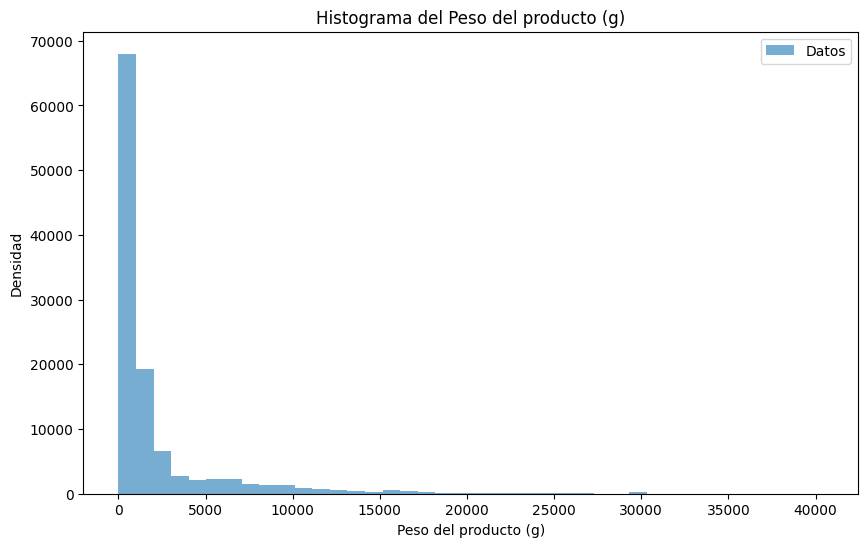

In [159]:
plt.figure(figsize=(10,6))

plt.hist(
    x,
    bins=40,
    alpha=0.6,
    label="Datos"
)

x_grid = np.linspace(x.min(), x.max(), 500)

plt.xlabel("Peso del producto (g)")
plt.ylabel("Densidad")
plt.title("Histograma del Peso del producto (g)")
plt.legend()
plt.show()

### Distribuciones candidatas para el peso del producto

A partir del histograma inicial de `product_weight_g`, se observa una distribución **unimodal, con fuerte asimetría hacia la derecha**: la mayoría de los productos concentra su peso en valores bajos, mientras que una cola larga de productos más pesados se extiende hacia la derecha. Esta forma descarta distribuciones simétricas (como la Normal) y orienta la búsqueda hacia familias paramétricas positivas y asimétricas, capaces de capturar tanto la concentración inicial como la cola larga observada.

Con base en esa forma, se seleccionan cuatro distribuciones paramétricas continuas y positivas, cada una con una interpretación física o de negocio razonable para el peso de un paquete en olist:

- **Log-Normal:** surge cuando el peso final resulta de la combinación **multiplicativa** de varios factores independientes (densidad del material, grosor del empaque, cantidad de unidades, etc.). Es la distribución típica de variables de manufactura y logística que no pueden ser negativas y presentan asimetría marcada hacia la derecha — coherente con la forma observada en el histograma.
- **Gamma:** generaliza la suma de varios componentes de peso positivos e independientes (por ejemplo, producto + empaque + relleno protector); ofrece flexibilidad similar a la Log-Normal, capaz de reproducir la misma asimetría, pero con un mecanismo generador distinto (aditivo en vez de multiplicativo).
- **Weibull:** tiene origen en teoría de valores extremos ("eslabón más débil"), y es razonable cuando el peso está condicionado por un proceso de control de calidad o empaque con un umbral mínimo; también permite representar colas asimétricas como la del histograma.
- **Exponencial:** se incluye como caso base (sin memoria, un solo parámetro) para verificar si las distribuciones más flexibles anteriores realmente aportan un mejor ajuste frente a la opción más simple posible.

Se excluyen deliberadamente distribuciones puramente flexibles sin interpretación física clara en este contexto (ej. Burr, Fisk, Log-Gamma), priorizando candidatas que puedan justificarse tanto por la forma observada en los datos como ante una pregunta de negocio, no solo ante una métrica estadística.

**Nota de limpieza:** se excluyen del ajuste los registros con `product_weight_g = 0`, por representar un valor físicamente imposible (error de captura en el dataset original), consistente con el criterio de no imputar ni forzar datos inválidos usado en el resto del proyecto.

In [160]:
from scipy import stats
import numpy as np
import pandas as pd

x = df_clean["product_weight_g"].dropna()
x = x[x > 0].values   # excluye ceros (error de captura documentado)
n = len(x)
print("Observaciones usadas (peso > 0):", n)

distribuciones_candidatas = ["lognorm", "gamma", "weibull_min", "expon"]

def chi2_gof_test(data, dist, params, n_bins=15):
    """
    Prueba Chi-cuadrado de bondad de ajuste, usando bins de igual
    probabilidad bajo la distribución ajustada (evita el problema de
    frecuencias esperadas muy bajas en las colas).
    """
    n = len(data)
    probs = np.linspace(0, 1, n_bins + 1)
    bin_edges = dist.ppf(probs, *params)
    bin_edges[0] = 0          # el peso real no puede ser negativo
    bin_edges[-1] = np.inf    # cola derecha abierta

    observed, _ = np.histogram(data, bins=bin_edges)
    expected = np.full(n_bins, n / n_bins)  # bins de igual prob. -> igual frecuencia esperada

    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    k_params = len(params)
    dof = n_bins - 1 - k_params   # se restan los parámetros estimados por MLE
    p_value = 1 - stats.chi2.cdf(chi2_stat, dof)

    return chi2_stat, dof, p_value

resultados = []

for nombre in distribuciones_candidatas:
    dist = getattr(stats, nombre)
    params = dist.fit(x, floc=0)
    loglik = np.sum(dist.logpdf(x, *params))
    k = len(params)
    aic = 2 * k - 2 * loglik
    bic = k * np.log(n) - 2 * loglik

    ks_stat, ks_pvalue = stats.kstest(x, nombre, args=params)
    chi2_stat, chi2_dof, chi2_pvalue = chi2_gof_test(x, dist, params)

    resultados.append({
        "distribucion": nombre, "params": params,
        "log_verosimilitud": loglik, "AIC": aic, "BIC": bic,
        "KS_estadistico": ks_stat, "KS_p_value": ks_pvalue,
        "Chi2_estadistico": chi2_stat, "Chi2_gl": chi2_dof, "Chi2_p_value": chi2_pvalue
    })

tabla_ajuste = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)
print(tabla_ajuste[["distribucion", "AIC", "BIC", "KS_estadistico", "KS_p_value",
                     "Chi2_estadistico", "Chi2_gl", "Chi2_p_value"]])

Observaciones usadas (peso > 0): 112624
  distribucion           AIC           BIC  KS_estadistico  KS_p_value  \
0      lognorm  1.890511e+06  1.890540e+06        0.065683         0.0   
1  weibull_min  1.918405e+06  1.918434e+06        0.115585         0.0   
2        gamma  1.929705e+06  1.929734e+06        0.138815         0.0   
3        expon  1.947666e+06  1.947685e+06        0.230832         0.0   

   Chi2_estadistico  Chi2_gl  Chi2_p_value  
0      12110.024187       11           0.0  
1      36326.180601       11           0.0  
2      41739.804251       11           0.0  
3      58467.465851       12           0.0  


### Resultado del ajuste

| Distribución | AIC | KS (estad.) | Chi² (estad.) |
|---|---|---|---|
| **Log-Normal** | **1.890.511** | **0.0657** | **12.110** |
| Weibull | 1.918.405 | 0.1156 | 36.326 |
| Gamma | 1.929.705 | 0.1388 | 41.740 |
| Exponencial | 1.947.666 | 0.2308 | 58.467 |

La distribución **Log-Normal** presenta el mejor ajuste entre las cuatro candidatas evaluadas: el menor AIC/BIC (indicando el mejor balance entre bondad de ajuste y complejidad del modelo), el menor estadístico KS y el menor estadístico Chi² — es decir, gana de forma consistente en las tres métricas, no solo en una. Esto es coherente con su interpretación física: el peso de un producto empacado depende de múltiples factores que se combinan de forma multiplicativa (material, tamaño, tipo de empaque), el mecanismo generador clásico detrás de una distribución Log-Normal.

**Sobre los p-values en 0.0:** tanto la prueba KS como la Chi-cuadrado rechazan la hipótesis nula (H₀: los datos provienen de la distribución ajustada) para las cuatro distribuciones, incluida la ganadora. Esto **no invalida el hallazgo**: con un tamaño de muestra tan grande (n = 112.624), ambas pruebas se vuelven extremadamente sensibles y detectan como "significativas" incluso desviaciones mínimas e irrelevantes en la práctica — es una limitación bien documentada de las pruebas de hipótesis clásicas aplicadas a big data, no un defecto del modelo. Por esta razón, la decisión sobre qué distribución usar se apoya en la **comparación relativa** entre candidatas (AIC, BIC, y las magnitudes de KS/Chi², no su significancia formal), donde la Log-Normal es sistemáticamente la de menor discrepancia frente a los datos observados.

**Conclusión:** se adopta la distribución Log-Normal como el modelo paramétrico que mejor describe el peso de los productos en el catálogo de Olist, tanto por evidencia estadística comparativa como por su coherencia con el proceso físico de generación del peso de un paquete.

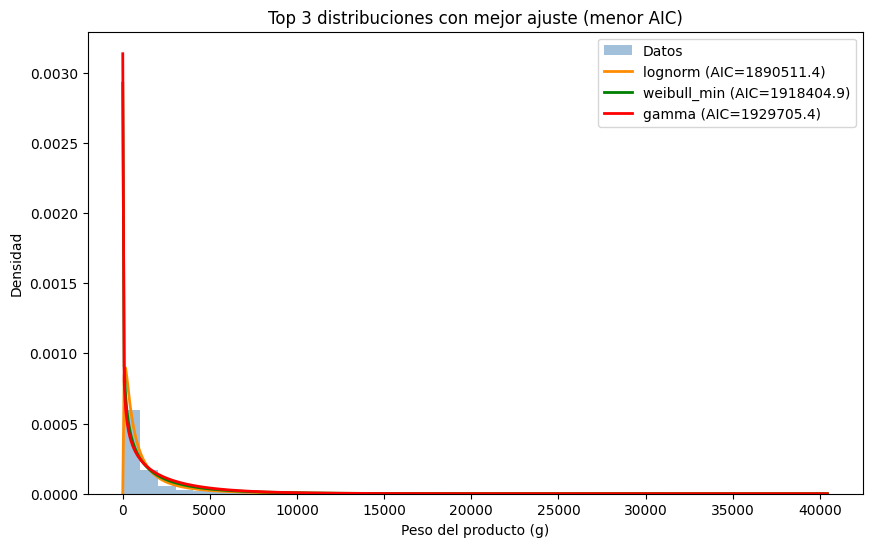


Mejor distribución según AIC: lognorm
Parámetros: (np.float64(1.3298308312968403), 0, np.float64(803.5224486363829))


In [161]:
plt.figure(figsize=(10, 6))

plt.hist(x, bins=40, density=True, alpha=0.5, label="Datos", color="steelblue")

x_grid = np.linspace(x.min(), x.max(), 500)
top3 = tabla_ajuste.head(3)

colores = ["darkorange", "green", "red"]
for (_, fila), color in zip(top3.iterrows(), colores):
    dist = getattr(stats, fila["distribucion"])
    plt.plot(x_grid, dist.pdf(x_grid, *fila["params"]),
              label=f"{fila['distribucion']} (AIC={fila['AIC']:.1f})",
              linewidth=2, color=color)

plt.xlabel("Peso del producto (g)")
plt.ylabel("Densidad")
plt.title("Top 3 distribuciones con mejor ajuste (menor AIC)")
plt.legend()
plt.show()

print(f"\nMejor distribución según AIC: {tabla_ajuste.iloc[0]['distribucion']}")
print(f"Parámetros: {tabla_ajuste.iloc[0]['params']}")

# Concepto 5 — Esperanza y varianza

**Pregunta de negocio:** ¿Cuál es el ticket promedio por categoría de producto, y en cuáles hay mayor variabilidad (riesgo)?

**Calcular el valor total del item (precio + flete)**

In [162]:
df_clean["valor_item"] = (
    df_clean["price"] +
    df_clean["freight_value"]
)

In [163]:
category_stats = (
    df_clean
    .groupby("product_category_name")["valor_item"] #obtener estadisticas por categoria
    .agg(
        esperanza="mean",
        varianza="var",
        desviacion="std",
        observaciones="count"
    )
    .sort_values("esperanza", ascending=False) #ordenar de mayor a menor varianza
)

category_stats.head(10)

,esperanza,varianza,desviacion,observaciones
product_category_name,,,,
pcs,1146.795222,457812.432072,676.618380,203
portateis_casa_forno_e_cafe,660.441711,390426.210217,624.840948,76
eletrodomesticos_2,520.663529,312471.187273,558.991223,238
agro_industria_e_comercio,369.689009,188230.115570,433.854948,212
instrumentos_musicais,309.025544,214665.607160,463.320199,680
eletroportateis,304.372356,232788.474371,482.481579,679
portateis_cozinha_e_preparadores_de_alimentos,285.219333,179009.193178,423.094780,15
telefonia_fixa,243.260644,181003.011259,425.444487,264
construcao_ferramentas_seguranca,229.193918,104668.491713,323.525102,194


Las categorias con mayor varianza ("Riesgo") fueron:


1.   ```pcs ```
2.   ```portateis_casa_forno_e_cafe ```
3.   ```eletrodomesticos_2 ```








# Concepto 6 — Independencia y correlación

**Pregunta de negocio:** ¿El método de pago y la categoría de producto son variables independientes? ¿Existe correlación entre el tiempo de entrega y la calificación del cliente?

**6.1 Independencia**

In [164]:
payments
primary_payment = (
    payments
    .sort_values(
        ["order_id", "payment_value"],
        ascending=[True, False]
    )
    [["order_id", "payment_type"]]
)
order_category_payment = (
    df_clean[
        [
            "order_id",
            "product_category_name"
        ]
    ]
    .dropna()
    .drop_duplicates()
    .merge(
        primary_payment,
        on="order_id",
        how="inner"
    )
)
order_category_payment["categoria_agrupada"] = np.where(
    order_category_payment["product_category_name"],
    order_category_payment["product_category_name"],
    "other"
)

**Tabla de contingencia**

In [165]:

tabla = pd.crosstab(
    order_category_payment["categoria_agrupada"],
    order_category_payment["payment_type"]
)

tabla

payment_type,boleto,credit_card,debit_card,not_defined,voucher
categoria_agrupada,,,,,
agro_industria_e_comercio,51,125,4,0,31
alimentos,99,330,17,0,20
alimentos_bebidas,55,165,2,0,15
artes,46,147,6,0,13
artes_e_artesanato,7,13,3,0,0
...,...,...,...,...,...
sinalizacao_e_seguranca,40,94,3,0,5
tablets_impressao_imagem,17,62,0,0,4
telefonia,945,3133,77,0,208


**Prueba chi-2**

**Hipótesis:** $$H_0=\text{método de pago y categoría son independientes}$$ $$H_1=\text{método de pago y categoría no son independientes}$$

In [166]:
chi2, p_value, dof, expected = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("p-value:", p_value)
print("Grados de libertad:", dof)

Chi-cuadrado: 1443.237784243638
p-value: 1.7827413582350877e-151
Grados de libertad: 292


Con $\alpha$ = 0.05, se rechaza $H_0$ por lo que existe evidencia de asociación entre las variables.

**6.2 Correlación**

In [167]:
correlation_analysis = (
    df_clean[
        ["order_id", "tiempo_entrega_dias"]
    ]
    .merge(
        reviews_analysis,
        on="order_id",
        how="inner"
    )
)

Correlación de spearman

In [168]:
rho, p_value = stats.spearmanr(
    correlation_analysis["tiempo_entrega_dias"],
    correlation_analysis["review_score"],
    nan_policy="omit"
)

print("Correlación de Spearman:", rho)
print("p-value:", p_value)

Correlación de Spearman: -0.22086276465719967
p-value: 0.0


Con un $\rho$ = -0.22086, existe una relación negativa debil entre el tiempo de entrega y el puntaje de la reseña.Es decir entre mayor es el tiempo de entrega menor es la puntuación en la reseña.

# Concepto 7 — Prior y posterior

**Pregunta de negocio:** ¿Cómo se puede estimar la confiabilidad de un vendedor nuevo, partiendo de un prior poblacional y actualizándolo con la evidencia de sus primeras ventas?

Definimos: $$\text{éxito=pedido entregado a tiempo}$$
Por lo tanto $$\theta_i=P(\text{entrga a tiempo|vendedor=s)}$$

In [169]:
seller_orders = (
    df_clean[
        [
            "order_id",
            "seller_id",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ]
    .dropna(subset=["seller_id"])
    .drop_duplicates(["order_id", "seller_id"])
    .copy()
)

seller_orders = seller_orders[
    seller_orders["order_delivered_customer_date"].notna()
].copy()

seller_orders["a_tiempo"] = (
    seller_orders["order_delivered_customer_date"] <=
    seller_orders["order_estimated_delivery_date"]
)

In [170]:
seller_orders = seller_orders.sort_values(
    ["seller_id", "order_purchase_timestamp"] #ordenar de venta mas vieja a mas reciente para cada vendedor
)

seller_orders["numero_venta"] = (
    seller_orders
    .groupby("seller_id")
    .cumcount() + 1 #enumera las ventas de cada vendedor, se suma 1 ya que la cuenta inicia en 0
)

**Prior**

Calcular la tasa global

In [171]:
tasa_global = seller_orders["a_tiempo"].mean()

print("Tasa global de entregas a tiempo:", tasa_global)

Tasa global de entregas a tiempo: 0.919799216905037


Se utilizara una distribución: $$\theta \sim Beta(\alpha_0,\beta_0)$$ usando la fuerza previa de 20 observaciones:

In [172]:
prior_strength = 20

alpha_0 = tasa_global * prior_strength
beta_0 = (1 - tasa_global) * prior_strength

print("Alpha prior:", alpha_0)
print("Beta prior:", beta_0)

Alpha prior: 18.39598433810074
Beta prior: 1.6040156618992607


**Posterior después de las primeras 10 ventas**

In [173]:
N = 10

first_n = seller_orders[
    seller_orders["numero_venta"] <= N
]

seller_posterior = (
    first_n
    .groupby("seller_id")["a_tiempo"]
    .agg(
        ventas="count",
        exitos="sum"
    )
    .reset_index()
)

seller_posterior["fracasos"] = (
    seller_posterior["ventas"] -
    seller_posterior["exitos"]
)

seller_posterior["alpha_posterior"] = (
    alpha_0 +
    seller_posterior["exitos"]
)

seller_posterior["beta_posterior"] = (
    beta_0 +
    seller_posterior["fracasos"]
)

seller_posterior["media_posterior"] = (
    seller_posterior["alpha_posterior"] /
    (
        seller_posterior["alpha_posterior"] +
        seller_posterior["beta_posterior"]
    )
)

**Calcular $P(\theta>0.9 | datos)$**


In [174]:
seller_posterior["prob_confiable"] = (
    1 -
    stats.beta.cdf(
        0.9,
        seller_posterior["alpha_posterior"],
        seller_posterior["beta_posterior"]
    )
)

**Definición del umbral de confiabilidad (θ = 0.9)**

Se define un vendedor como "confiable" si su tasa real de entregas a tiempo supera θ = 0.9. Este umbral no es arbitrario: se ancla en la tasa global observada en el dataset (91%), redondeada hacia abajo. Redondear evita una falsa precisión sobre la tasa muestral exacta, mientras mantiene el umbral cerca del desempeño promedio real de la red — de modo que "confiable" siga significando igualar o superar el estándar de la mayoría, no un listón trivialmente bajo.

```prob_confiable``` responde entonces a la pregunta: dada la evidencia observada de sus primeras N ventas, ¿qué tan probable es que la tasa real de este vendedor supere el estándar de 90%?

In [175]:
seller_posterior

,seller_id,ventas,exitos,fracasos,alpha_posterior,beta_posterior,media_posterior,prob_confiable
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,0,21.395984,1.604016,0.930260,0.768764
1,001cca7ae9ae17fb1caed9dfb1094831,10,10,0,28.395984,1.604016,0.946533,0.874642
2,002100f778ceb8431b7a1020ff7ab48f,10,9,1,27.395984,2.604016,0.913199,0.663662
3,003554e2dce176b5555353e4f3555ac8,1,1,0,19.395984,1.604016,0.923618,0.726068
4,004c9cd9d87a3c30c522c48c4fc07416,10,9,1,27.395984,2.604016,0.913199,0.663662
...,...,...,...,...,...,...,...,...
2965,ffc470761de7d0232558ba5e786e57b7,10,9,1,27.395984,2.604016,0.913199,0.663662
2966,ffdd9f82b9a447f6f8d4b91554cc7dd3,10,10,0,28.395984,1.604016,0.946533,0.874642
2967,ffeee66ac5d5a62fe688b9d26f83f534,10,9,1,27.395984,2.604016,0.913199,0.663662
2968,fffd5413c0700ac820c7069d66d98c89,10,9,1,27.395984,2.604016,0.913199,0.663662


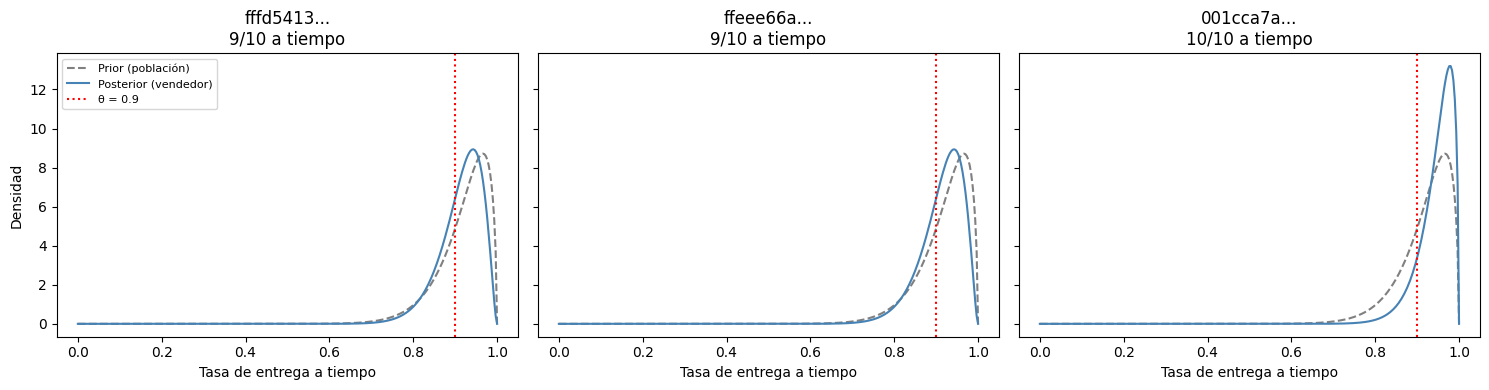

In [176]:

# Elige 3 vendedores de ejemplo con distinto número de ventas / desempeño
ejemplos = seller_posterior.sort_values("ventas", ascending=False).iloc[[0, 1, 2]]

x = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, len(ejemplos), figsize=(15, 4), sharey=True)

for ax, (_, row) in zip(axes, ejemplos.iterrows()):
    ax.plot(x, stats.beta.pdf(x, alpha_0, beta_0),
            label="Prior (población)", linestyle="--", color="gray")
    ax.plot(x, stats.beta.pdf(x, row["alpha_posterior"], row["beta_posterior"]),
            label="Posterior (vendedor)", color="steelblue")
    ax.axvline(0.9, color="red", linestyle=":", label=f"θ = {0.9}")
    ax.set_title(f"{row['seller_id'][:8]}...\n{int(row['exitos'])}/{int(row['ventas'])} a tiempo")
    ax.set_xlabel("Tasa de entrega a tiempo")

axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Concepto 8 — Entropía

**Pregunta de negocio:** ¿Qué tan diversa o concentrada es la distribución de categorías de producto (o de métodos de pago) en el catálogo de Olist?

Usando la fórmula de la entropia: $H(X)=-\sum_ilog(p_i)$

In [177]:
entropy_data = (
    df_clean[
        [
            "order_id",
            "product_category_name"
        ]
    ]
    .dropna(  subset=[ "product_category_name"])
).copy()


**Calculo de la entropia**

Para calcular la entropía se tomó como unidad de observación el ítem de producto vendido. No se eliminaron las repeticiones de categorías, ya que cada aparición representa un producto vendido y permite obtener la frecuencia real de participación de cada categoría. A partir de estas frecuencias se calcularon las probabilidades de cada categoría sobre el total de ítems y posteriormente la entropía de Shannon.

In [178]:
category_counts = (
    entropy_data["product_category_name"]
    .value_counts()
)

p = category_counts / category_counts.sum()

entropia_observada  = -(p * np.log(p)).sum()

print("Entropía:", entropia_observada )

Entropía: 3.3025767296989987


**Entropia máxima teórica**


In [180]:
K = len(p)

entropia_maxima = np.log(K)

print("Número de categorías:", K)
print(f"Entropía observada: {entropia_observada :.4f}")
print(f"Entropía máxima teórica: {entropia_maxima:.4f}")

Número de categorías: 74
Entropía observada: 3.3026
Entropía máxima teórica: 4.3041


**Entropia normalizada**

In [193]:
porcentaje_entropia = (
    entropia_observada  / entropia_maxima
) * 100

print(
    f"La entropía observada representa "
    f"el {porcentaje_entropia:.2f}% "
    f"de la máxima teórica."
)

La entropía observada representa el 76.73% de la máxima teórica.


La entropía normalizada de la distribución de categorías de producto es 76.73%, lo que indica un catálogo con diversidad moderada-alta: Olist no depende de un puñado de categorías dominantes.Pero tampoco distribuye sus ventas de forma perfectamente uniforme entre todas las categorías disponibles. El resultado sugiere un catálogo amplio con algunas categorías más populares que otras, pero sin una concentración extrema en unas pocas categorías.

# Concepto 9 — Entropía cruzada

**Pregunta de negocio:** ¿Qué tan bien puede un modelo simple predecir si una reseña será positiva o negativa a partir de las variables del pedido?

In [194]:
reviews_model = reviews_analysis.copy()

reviews_model["target"] = (
    reviews_model["review_score"] <= 2
).astype(int)

Vamos a utilizar variables que conocemos después de la compra:

* tardio
* número de cuotas
* valor pagado

In [195]:
payments_order = (
    data["olist_order_payments_dataset"]
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max")
    )
    .reset_index()
)

Crear caracteristicas de pedido

In [196]:
order_features = (
    orders_analysis[
        ["order_id", "tardio"]
    ]
    .merge(
        payments_order,
        on="order_id",
        how="left"
    )
)
order_features

,order_id,tardio,payment_value,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,False,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,False,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,False,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,False,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,False,28.62,1.0
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,False,85.08,3.0
99437,63943bddc261676b46f01ca7ac2f7bd8,False,195.00,3.0
99438,83c1379a015df1e13d02aae0204711ab,False,271.01,5.0
99439,11c177c8e97725db2631073c19f07b62,False,441.16,4.0


Agregar la columna target (Reseña positiva o negativa)

In [197]:
order_features = order_features.merge(
    reviews_model[["order_id","target"]],
    on="order_id",
    how="left"
)
order_features

,order_id,tardio,payment_value,payment_installments,target
0,e481f51cbdc54678b7cc49136f2d6af7,False,38.71,1.0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,False,141.46,1.0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,False,179.12,3.0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,False,72.20,1.0,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,False,28.62,1.0,0.0
...,...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,False,85.08,3.0,0.0
99988,63943bddc261676b46f01ca7ac2f7bd8,False,195.00,3.0,0.0
99989,83c1379a015df1e13d02aae0204711ab,False,271.01,5.0,0.0
99990,11c177c8e97725db2631073c19f07b62,False,441.16,4.0,1.0


In [198]:
features = [
    "tardio",
    "payment_value",
    "payment_installments"
]

order_features = order_features.dropna(
    subset=['payment_value', 'payment_installments',"target"]
)

División entrenamiento/validación

No debemos permitir que reseñas del mismo pedido caigan unas en entrenamiento y otras en validación.Para evitar fuga de datos, es decir que el modelo se entrene con información del conjunto de testeo.

In [199]:
X = order_features[features]
y = order_features["target"]
groups = order_features["order_id"]

gss = GroupShuffleSplit( #asegurar que los grupos del mismo order_id esten juntos en test o train
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

Crear la regresión logistica

In [200]:
model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=1000
        )
    )
])

Entrenar el modelo

In [201]:
model.fit(X_train, y_train)
p_train = model.predict_proba(X_train)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]

**Calculo de la entropia cruzada en el conjunto test y test**

Usando la función log_loss() de ```sklearn```



In [202]:
ce_train = log_loss(y_train, p_train)
ce_test = log_loss(y_test, p_test)

print(f"Entropía cruzada (train): {ce_train:.4f}")
print(f"Entropía cruzada (test):  {ce_test:.4f}")

Entropía cruzada (train): 0.3779
Entropía cruzada (test):  0.3836


Calculo paso a paso de la entropia cruzada:

*Fundamento teórico del proceso.*

La **entropía cruzada** entre dos distribuciones de probabilidad $p$ (la distribución real) y $q$ (la distribución predicha por el modelo) se define, para un conjunto de posibles resultados $x$, como:

$$
H(p, q) = -\sum_{x} p(x)\,\log q(x)
$$

Esta cantidad mide, en promedio, cuántos "bits de sorpresa" produce el modelo $q$ cuando la verdad proviene en realidad de $p$. Se minimiza cuando $q = p$, caso en el que $H(p,q)$ coincide con la entropía propia de $p$.

### Caso binario

En este problema, la variable objetivo $y_i \in \{0, 1\}$ indica si el pedido $i$ recibió una reseña negativa ($y_i = 1$) o no ($y_i = 0$). Para cada observación, la distribución real es degenerada:

$$
p(1) = y_i, \qquad p(0) = 1 - y_i
$$

y el modelo predice una probabilidad $\hat{y}_i = P(y_i = 1 \mid x_i)$, con $1-\hat{y}_i$ como probabilidad complementaria. Sustituyendo en la definición general para los dos únicos resultados posibles ($x \in \{0,1\}$):

$$
H(p, q)_i = -\Big[\, y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \,\Big]
$$

Nótese que uno de los dos términos siempre se anula, dependiendo del valor real de $y_i$:

$$
H(p,q)_i =
\begin{cases}
-\log(\hat{y}_i) & \text{si } y_i = 1 \\[4pt]
-\log(1-\hat{y}_i) & \text{si } y_i = 0
\end{cases}
$$

es decir, el modelo se penaliza en función de qué tan lejos estuvo su probabilidad predicha del resultado real observado.

### Promedio sobre el conjunto de datos

Para obtener una medida agregada del desempeño del modelo sobre un conjunto de $n$ observaciones (entrenamiento o prueba), se promedia la entropía cruzada individual de cada pedido:

$$
H(y, \hat{y}) = -\frac{1}{n}\sum_{i=1}^{n}\Big[\, y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \,\Big]
$$

Esta expresión corresponde exactamente a la función de pérdida *log loss* utilizada por `sklearn.metrics.log_loss`, y es la que se implementó de forma manual para verificar su equivalencia con la función de la librería.

**Nota numérica:** dado que $\log(0)$ no está definido, las probabilidades predichas $\hat{y}_i$ se acotan mediante `np.clip(y_pred, eps, 1-eps)` con $\varepsilon \approx 10^{-15}$, evitando indeterminaciones sin alterar de forma perceptible el resultado del cálculo.

In [203]:
def entropia_cruzada_manual(y_true, y_pred, eps=1e-15):
    # eps evita log(0) cuando el modelo predice probabilidad exactamente 0 o 1
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

ce_train_manual = entropia_cruzada_manual(y_train.values, p_train)
ce_test_manual = entropia_cruzada_manual(y_test.values, p_test)

print(f"Entropía cruzada manual (train): {ce_train_manual:.4f}")
print(f"Entropía cruzada manual (test):  {ce_test_manual:.4f}")

Entropía cruzada manual (train): 0.3779
Entropía cruzada manual (test):  0.3836


# Concepto 10 — Divergencia KL

**Pregunta de negocio:** ¿Qué tan diferente es la percepción de calidad (distribución de calificaciones) entre dos estados de Brasil?

In [204]:
reviews_estado = (
    df_clean[["order_id", "customer_state"]]
    .drop_duplicates("order_id")
    .merge(reviews_analysis, on="order_id", how="inner")  # reviews_ultima ya la definiste en Concepto 1
)
reviews_estado

,order_id,customer_state,review_id,review_score,order_delivered_customer_date,order_estimated_delivery_date,tardio,reseña_negativa
0,e481f51cbdc54678b7cc49136f2d6af7,SP,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-10 21:25:13,2017-10-18,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,BA,8d5266042046a06655c8db133d120ba5,4,2018-08-07 15:27:45,2018-08-13,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,GO,e73b67b67587f7644d5bd1a52deb1b01,5,2018-08-17 18:06:29,2018-09-04,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,359d03e676b3c069f62cadba8dd3f6e8,5,2017-12-02 00:28:42,2017-12-15,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,e50934924e227544ba8246aeb3770dd4,5,2018-02-16 18:17:02,2018-02-26,False,False
...,...,...,...,...,...,...,...,...
99219,9c5dedf39a927c1b2549525ed64a053c,SP,e262b3f92d1ce917aa412a9406cf61a6,5,2017-03-17 15:08:01,2017-03-28,False,False
99220,63943bddc261676b46f01ca7ac2f7bd8,SP,29bb71b2760d0f876dfa178a76bc4734,4,2018-02-28 17:37:56,2018-03-02,False,False
99221,83c1379a015df1e13d02aae0204711ab,BA,371579771219f6db2d830d50805977bb,5,2017-09-21 11:24:17,2017-09-27,False,False
99222,11c177c8e97725db2631073c19f07b62,RJ,8ab6855b9fe9b812cd03a480a25058a1,2,2018-01-25 23:32:54,2018-02-15,False,True


Se realiza la comparación con los estados SP y RJ

In [205]:
estado_A = "SP"
estado_B = "RJ"

n_A = (reviews_estado["customer_state"] == estado_A).sum()
n_B = (reviews_estado["customer_state"] == estado_B).sum()
print(f"Pedidos con reseña — {estado_A}: {n_A} | {estado_B}: {n_B}")

Pedidos con reseña — SP: 41690 | RJ: 12765


Calcular las distribuciones de los puntajes en ambos estados:

In [206]:
def distribucion_scores(df, estado, eps=1e-6):
    conteo = (
        df[df["customer_state"] == estado]["review_score"]
        .value_counts()
        .reindex([1, 2, 3, 4, 5], fill_value=0)
        .sort_index()
    )
    prob = conteo / conteo.sum()
    prob = prob + eps # Suavizado: evita ceros exactos (KL no está definida si Q(x)=0 y P(x)>0)
    prob = prob / prob.sum()
    return prob

P = distribucion_scores(reviews_estado, estado_A)
Q = distribucion_scores(reviews_estado, estado_B)

print(f"\nDistribución {estado_A}:\n{P}")
print(f"\nDistribución {estado_B}:\n{Q}")


Distribución SP:
review_score
1    0.097242
2    0.029049
3    0.079132
4    0.191677
5    0.602900
Name: count, dtype: float64

Distribución RJ:
review_score
1    0.171015
2    0.036350
3    0.082257
4    0.167411
5    0.542967
Name: count, dtype: float64


Calculo de la divergencia KL.

*Fundamento teórico — Divergencia de Kullback-Leibler (KL)*

La **divergencia KL** cuantifica qué tan diferente es una distribución de probabilidad $P$ respecto a una distribución de referencia $Q$, definidas sobre el mismo espacio de resultados $x$:

$$
D_{KL}(P \parallel Q) = \sum_{x} P(x)\,\log\frac{P(x)}{Q(x)}
$$

En este análisis, $P$ y $Q$ son las distribuciones empíricas de `review_score` (1 a 5 estrellas) para dos estados de Brasil. $D_{KL}(P \parallel Q) = 0$ si y solo si $P = Q$; valores mayores indican distribuciones más distintas entre sí.

**Propiedad clave — asimetría:** a diferencia de una distancia matemática convencional, la divergencia KL **no es simétrica**:

$$
D_{KL}(P \parallel Q) \neq D_{KL}(Q \parallel P)
$$

Por esta razón se reportan ambas direcciones. $D_{KL}(P\parallel Q)$ mide cuánta "sorpresa" produce observar $Q$ si la distribución esperada era $P$ (y viceversa).

**Nota numérica:** cuando $Q(x) = 0$ para algún valor con $P(x) > 0$, el cociente $P(x)/Q(x)$ no está definido. Para evitarlo, ambas distribuciones se suavizan añadiendo una probabilidad mínima $\varepsilon$ antes de normalizar.

In [207]:
kl_manual = np.sum(P * np.log(P / Q))

# Verificación con scipy
kl_scipy = entropy(P, Q)  # entropy(P, Q) calcula KL(P || Q)

print(f"\nD_KL({estado_A} || {estado_B}) manual: {kl_manual:.4f}")
print(f"D_KL({estado_A} || {estado_B}) scipy:  {kl_scipy:.4f}")

kl_inversa = entropy(Q, P)# la KL NO es simétrica — calcula también la dirección opuesta
print(f"D_KL({estado_B} || {estado_A}): {kl_inversa:.4f}")


D_KL(SP || RJ) manual: 0.0246
D_KL(SP || RJ) scipy:  0.0246
D_KL(RJ || SP): 0.0284


La divergencia KL entre las distribuciones de calificaciones de São Paulo y Río de Janeiro es baja (D_KL(SP‖RJ) = 0.0246, D_KL(RJ‖SP) = 0.0284), lo que indica que la percepción de calidad del servicio es prácticamente equivalente entre ambos estados — a pesar de ser los dos mercados más grandes de Olist y tener perfiles logísticos distintos, no se observa una divergencia relevante en cómo califican sus clientes. La ligera asimetría (RJ como referencia genera más "sorpresa" al comparar con SP que al revés) sugiere que RJ tiene una distribución marginalmente más dispersa en los extremos, aunque la diferencia es pequeña en términos absolutos.

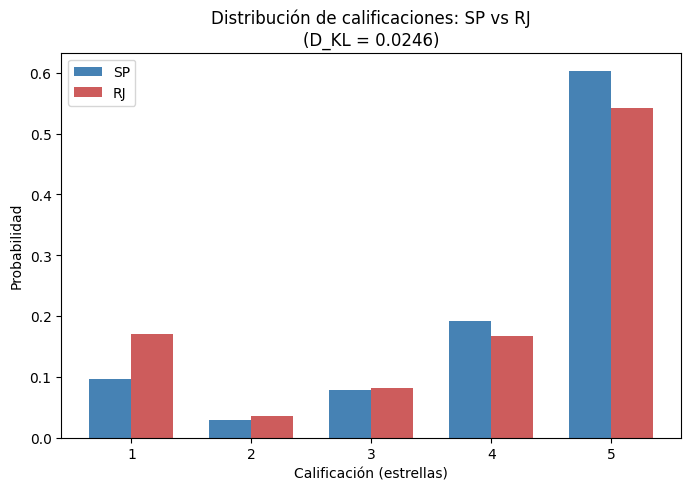

In [208]:
import matplotlib.pyplot as plt

x = np.arange(1, 6)
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, P.values, width, label=estado_A, color="steelblue")
plt.bar(x + width/2, Q.values, width, label=estado_B, color="indianred")
plt.xlabel("Calificación (estrellas)")
plt.ylabel("Probabilidad")
plt.xticks(x)
plt.title(f"Distribución de calificaciones: {estado_A} vs {estado_B}\n(D_KL = {kl_scipy:.4f})")
plt.legend()
plt.show()